In [ ]:
pip install --upgrade pip

In [ ]:
pip install numpy pandas scipy scikit-learn

НАЧАЛО ЗАГРУЗКИ ДАННЫХ

In [ ]:
pip uninstall matplotlib

Found existing installation: matplotlib 3.10.0
Uninstalling matplotlib-3.10.0:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/matplotlib-3.10.0.dist-info/*
    /usr/local/lib/python3.12/dist-packages/matplotlib/*
    /usr/local/lib/python3.12/dist-packages/mpl_toolkits/axes_grid1/*
    /usr/local/lib/python3.12/dist-packages/mpl_toolkits/axisartist/*
    /usr/local/lib/python3.12/dist-packages/mpl_toolkits/mplot3d/*
    /usr/local/lib/python3.12/dist-packages/pylab.py
Proceed (Y/n)? y
  Successfully uninstalled matplotlib-3.10.0


In [ ]:
pip install matplotlib==3.9.0 #работаем только с этой версией библиотеки

In [ ]:
from keras.datasets import mnist #импортируем набор MNIST

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
print('X_train: ' + str(X_train.shape))
print('Y_train: ' + str(y_train.shape))
print('X_test:  '  + str(X_test.shape))
print('Y_test:  '  + str(y_test.shape))

X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


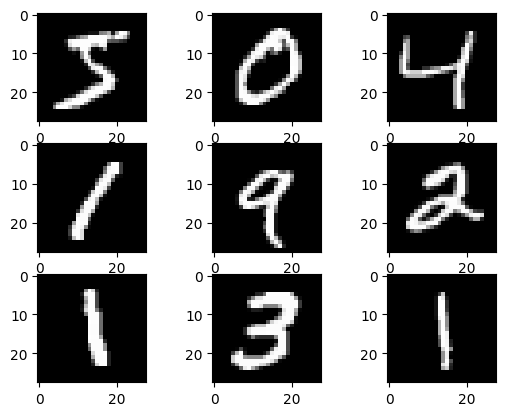

In [ ]:
from matplotlib import pyplot
for i in range(9):
    pyplot.subplot(330 + 1 + i)
    pyplot.imshow(X_train[i], cmap=pyplot.get_cmap('gray'))
pyplot.show()

In [ ]:
print('start of y_train:', y_train[:10])

start of y_train: [5 0 4 1 9 2 1 3 1 4]


In [ ]:
image_height = X_train.shape[1]

image_width = X_train.shape[2]

number_of_pixels = image_height * image_width
print(number_of_pixels)

784


In [ ]:
from keras import backend as keras_backend #импортируем настройки керас

In [ ]:
# конвертирование в плавающую точку
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [ ]:
# масштабирование данных в интервал [0, 1]
X_train /= 255.0
X_test /= 255.0

In [ ]:
from tensorflow.keras.utils import to_categorical
# печать первых 5 входов оригинального массива y_train array
print(y_train[:5])
y_train[:5]

[5 0 4 1 9]


array([5, 0, 4, 1, 9], dtype=uint8)

In [ ]:
# объединение списков входа для нахождения наибольшей величины
# в списке, затем добавление 1, потому что величина начинается с 0
import numpy as np
number_of_classes = int(1 + max(np.append(y_train, y_test)))
number_of_classes

10

Функция to_catigorical() просматривает массив целых чисел,
находит наибольшую величину и поэтому знает, как много нулей необходимо
представить для всех величин, подлежащих кодированию. Затем производится индивидуальное кодирование для каждого целого числа в списке. Выходом to_catigorical() является список этих кодировок, который представляет собой
список нулей и единиц. У нас десять цифр, поэтому десять элементов в строке. Единица в строке показывает какое число закодировано. В первой строке - единица идет после 5ти нулей. Значит кодирует число 5. и т.д.  

In [ ]:
# кодирование каждого списка в массивы индивидуальных параметров размера,
# который мы только что нашли

y_train = to_categorical(y_train, num_classes=number_of_classes)
y_test = to_categorical(y_test, num_classes=number_of_classes)

In [ ]:
y_train[:5]#проверим как выглядят первые 5 элементов ([5 0 4 1 9]) после категоризации

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [ ]:
X_train.shape[0]

60000

In [ ]:
# переформатирование изображения с помощью метода reshape к виду -  одна строка на изображение
X_train = np.reshape(X_train, [X_train.shape[0], number_of_pixels])
X_test = np.reshape(X_test, [X_test.shape[0], number_of_pixels])
X_train = X_train.reshape([X_train.shape[0], number_of_pixels])
X_test = X_test.reshape([X_test.shape[0], number_of_pixels])

Второй аргумент для reshape() – список с новыми размерностями. В этом случае
второй аргумент – это список (60 000, 784).

In [ ]:
X_train[100][10:]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
y_train


array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

######################конец подготовки данных!######################

Создадим теперь модель нейросети - 784 входных нейрона, скрытый слой 784 на 10 нейронов и выходной слой -10 нейронов

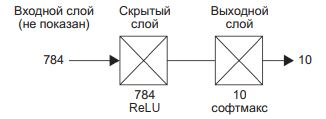

In [ ]:
#создаем модель сети последовательных слоев - Sequential
from keras.models import Sequential
model = Sequential()


In [ ]:
#Создаем первый "Плотный" (полносвязный) слой Dense
# первый параметр - размер слоя, второй - тип функции активации:
# relu - выпрямленная линейная функция
# tagh - гиперболичекий тангенс
# softmax - сглаженная ступенчатая
# sigmoid - сигмоида
# третий - указываем что слой входной
from keras.layers import Dense

dense_layer = Dense(number_of_pixels, activation='relu', input_shape=[number_of_pixels])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# добавление нашего списка в список слоев модели
model.add(dense_layer)

# можно так : model.add(Dense(number_of_pixels, activation='relu', input_shape=[number_of_pixels]))

In [ ]:
#добавляем второй слой из 10ти нейронов
model.add(Dense(number_of_classes, activation='softmax'))

In [ ]:
# посмотрим, как выглядит модель:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,290 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

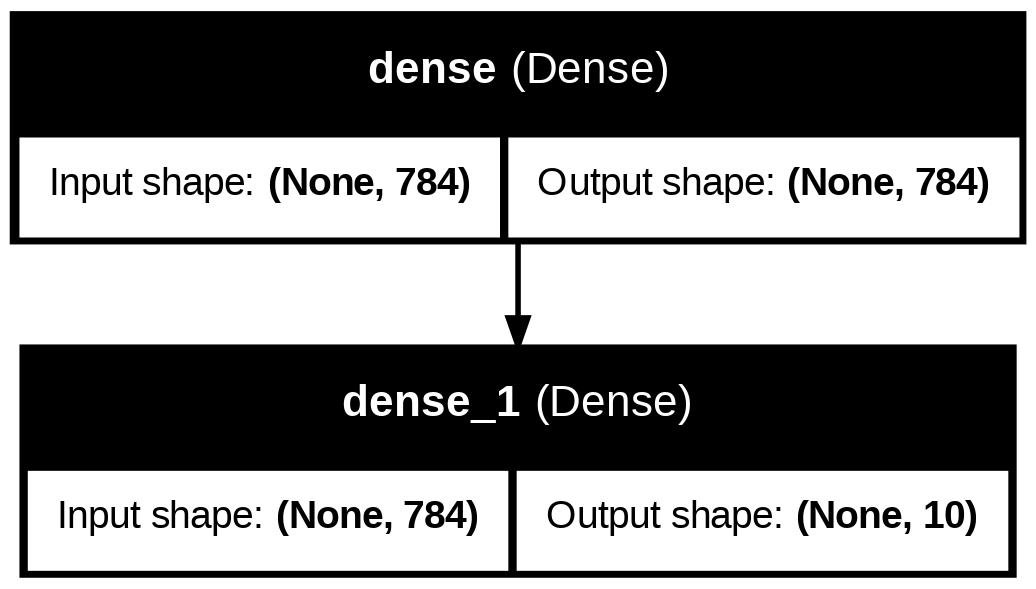

In [ ]:
# посмотрим, как она выглядит в виде схемы:
from keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
# компиляция модели для превращения ее из спецификации в код
# model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=256, verbose=2)
#history = model.fit(X_train, y_train, validation_split=0.25, epochs=10, batch_size=256, verbose=1)

Epoch 1/30
235/235 - 5s - 20ms/step - accuracy: 0.9171 - loss: 0.2967 - val_accuracy: 0.9578 - val_loss: 0.1485
Epoch 2/30
235/235 - 1s - 3ms/step - accuracy: 0.9647 - loss: 0.1219 - val_accuracy: 0.9688 - val_loss: 0.1032
Epoch 3/30
235/235 - 1s - 3ms/step - accuracy: 0.9772 - loss: 0.0809 - val_accuracy: 0.9724 - val_loss: 0.0853
Epoch 4/30
235/235 - 1s - 3ms/step - accuracy: 0.9836 - loss: 0.0576 - val_accuracy: 0.9762 - val_loss: 0.0740
Epoch 5/30
235/235 - 1s - 3ms/step - accuracy: 0.9874 - loss: 0.0429 - val_accuracy: 0.9786 - val_loss: 0.0678
Epoch 6/30
235/235 - 1s - 3ms/step - accuracy: 0.9909 - loss: 0.0327 - val_accuracy: 0.9762 - val_loss: 0.0741
Epoch 7/30
235/235 - 1s - 3ms/step - accuracy: 0.9939 - loss: 0.0249 - val_accuracy: 0.9808 - val_loss: 0.0602
Epoch 8/30
235/235 - 1s - 3ms/step - accuracy: 0.9956 - loss: 0.0188 - val_accuracy: 0.9774 - val_loss: 0.0693
Epoch 9/30
235/235 - 1s - 3ms/step - accuracy: 0.9972 - loss: 0.0141 - val_accuracy: 0.9818 - val_loss: 0.0591


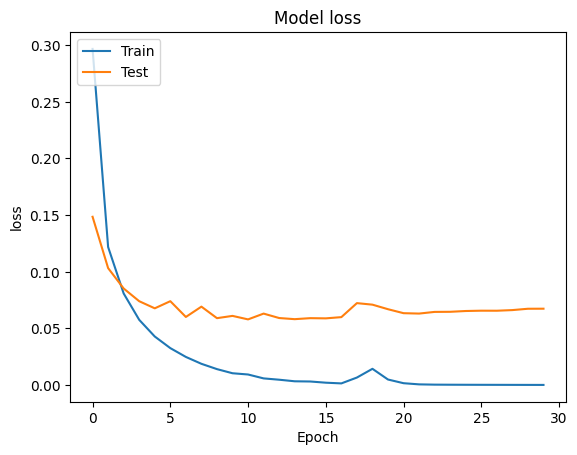

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')

plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

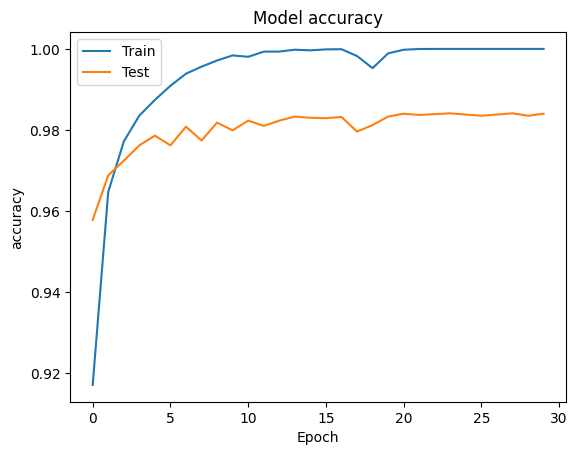

In [ ]:
import matplotlib.pyplot as plt1
plt1.plot(history.history['accuracy'])
plt1.plot(history.history['val_accuracy'])
plt.title('Model accuracy')

plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

**Загрузка и сохранение нейронной сети на диске Гугл**

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [ ]:
model.save('NeuroModels/Two_layer_model.h5') #Сохраняем модель

In [ ]:
# Как загрузить ранее сохраненную модель с весами с гугл-диска
from keras.models import load_model
#model2 = load_model('SavedModels/One_layer_model.h5')
model2 = load_model('NeuroModels/Two_layer_model.h5')

In [ ]:
# Как сохранить только веса модели
model.save_weights('NeuroModels/One_layer_model_weights_only.weights.h5')

In [ ]:
#Как загрузить только веса в существующую модель
#from keras.models import make_model
#model2 = make_model()
model.load_weights('NeuroModels/One_layer_model_weights_only.weights.h5')

In [ ]:
# как сохранить только архитектуру сети без весов, используя JSON
import json

filename = 'NeuroModels/One_layer_model_architecture_only.h5'

# Получаем архитектуру в формате JSON
json_string = model.to_json()

# Сохраняем строку в файл
with open(filename, 'w') as outfile:
    outfile.write(json_string)

In [ ]:
# как загрузить только архитектуру сети без весов, используя JSON (замена устаревшему YAML)
from keras.models import model_from_json

filename = 'NeuroModels/One_layer_model_architecture_only.h5'

with open(filename, 'r') as json_file:
    loaded_model_json = json_file.read()

# Загружаем архитектуру из JSON строки
model = model_from_json(loaded_model_json)

In [ ]:
%ls drive/MyDrive/Pics/ -a


1/  2/  3/  4/  5/  6/


**Исследование модели на проверочном наборе - картинки цифр прозвольные**

In [ ]:
import random
from PIL import Image, ImageDraw #Подключим необходимые библиотеки.
import matplotlib.pyplot as plt

digit_classes=['Цифра 0','Цифра 1','Цифра 2','Цифра 3','Цифра 4',
               'Цифра 5','Цифра 6','Цифра 7','Цифра 8','Цифра 9']

In [ ]:
import os
import numpy as np
from PIL import Image, ImageOps

def resize_to_gray_pic(f_name):
    # Открываем изображение и конвертируем в L (grayscale) сразу
    img = Image.open(f_name).convert('L')
    # Приводим к размеру 28x28
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    # Инвертируем цвета: MNIST - это белые цифры на черном фоне
    img = ImageOps.invert(img)
    return img

base_path = 'drive/MyDrive/Pics/'

# Проходим по всем папкам и файлам
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(root, file)

            # Предобработка
            image = resize_to_gray_pic(full_path)
            img_array = np.array(image).astype('float32')
            img_array /= 255.0

            # Решейп для модели (1 строка, 784 пикселя)
            img_input = img_array.reshape(1, number_of_pixels)

            # Предсказание
            prediction = model.predict(img_input, verbose=0)
            predicted_class = np.argmax(prediction, axis=-1)[0]
            probability = prediction[0][predicted_class]

            print(f"Файл: {file} | Папка: {os.path.basename(root)}")
            print(f"Предсказание: {digit_classes[predicted_class]}, Вероятность: {probability:.4f}")
            print("-" * 30)